In [1]:
# Import modules
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Load penguine dataset
penguins = sns.load_dataset('penguins')

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


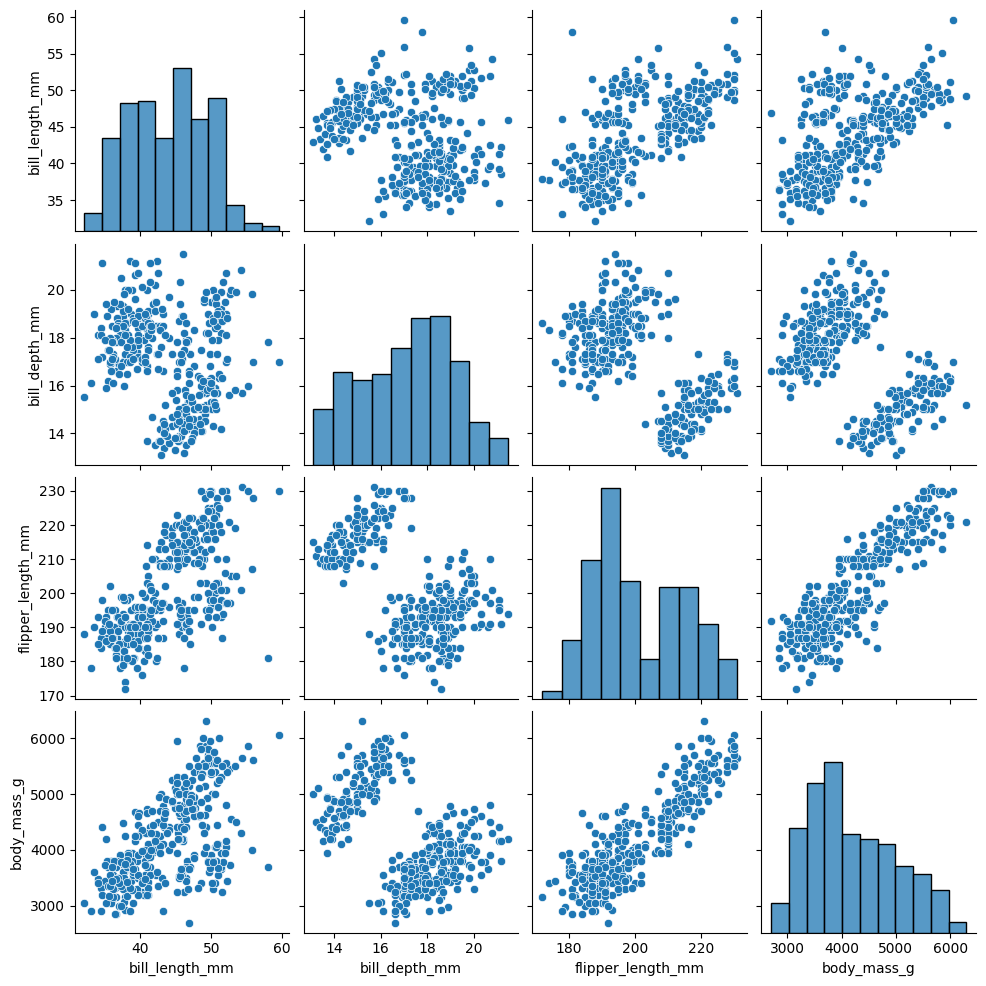

In [2]:
# Create a pair plot
sns.pairplot(penguins)
plt.show()

#### Correlations 
##### Flipper length ↔ body mass: strong positive relationship. Penguins with longer flippers tend to be heavier
##### Bill length ↔ flipper length: positive relationship.
##### Bill length ↔ body mass: positive relationship.
##### Bill depth behaves somewhat differently and has weaker relationships with some of the other variables.

In [3]:
correlation_matrix = penguins.select_dtypes('number').corr()
print(correlation_matrix)

                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.235053           0.656181   
bill_depth_mm           -0.235053       1.000000          -0.583851   
flipper_length_mm        0.656181      -0.583851           1.000000   
body_mass_g              0.595110      -0.471916           0.871202   

                   body_mass_g  
bill_length_mm        0.595110  
bill_depth_mm        -0.471916  
flipper_length_mm     0.871202  
body_mass_g           1.000000  


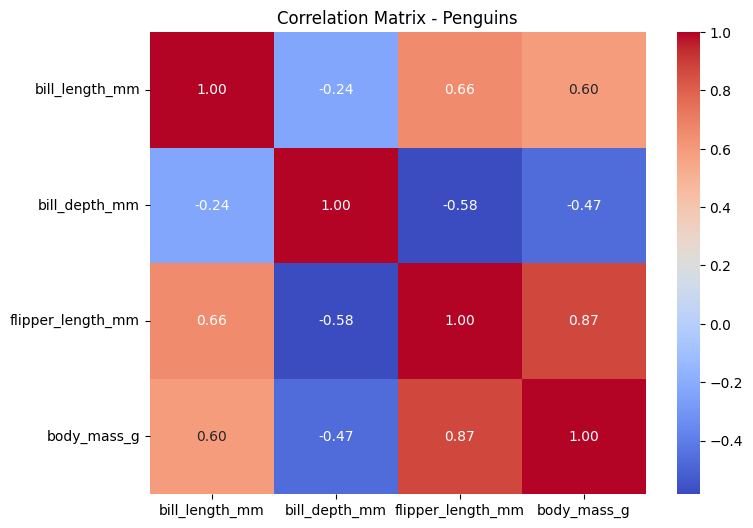

In [4]:
# Visualize it
plt.figure(figsize = (8,6))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Matrix - Penguins')
plt.show()

#### The flipper length and body mass relationship is one of the strongest positive correlations in this dataset.

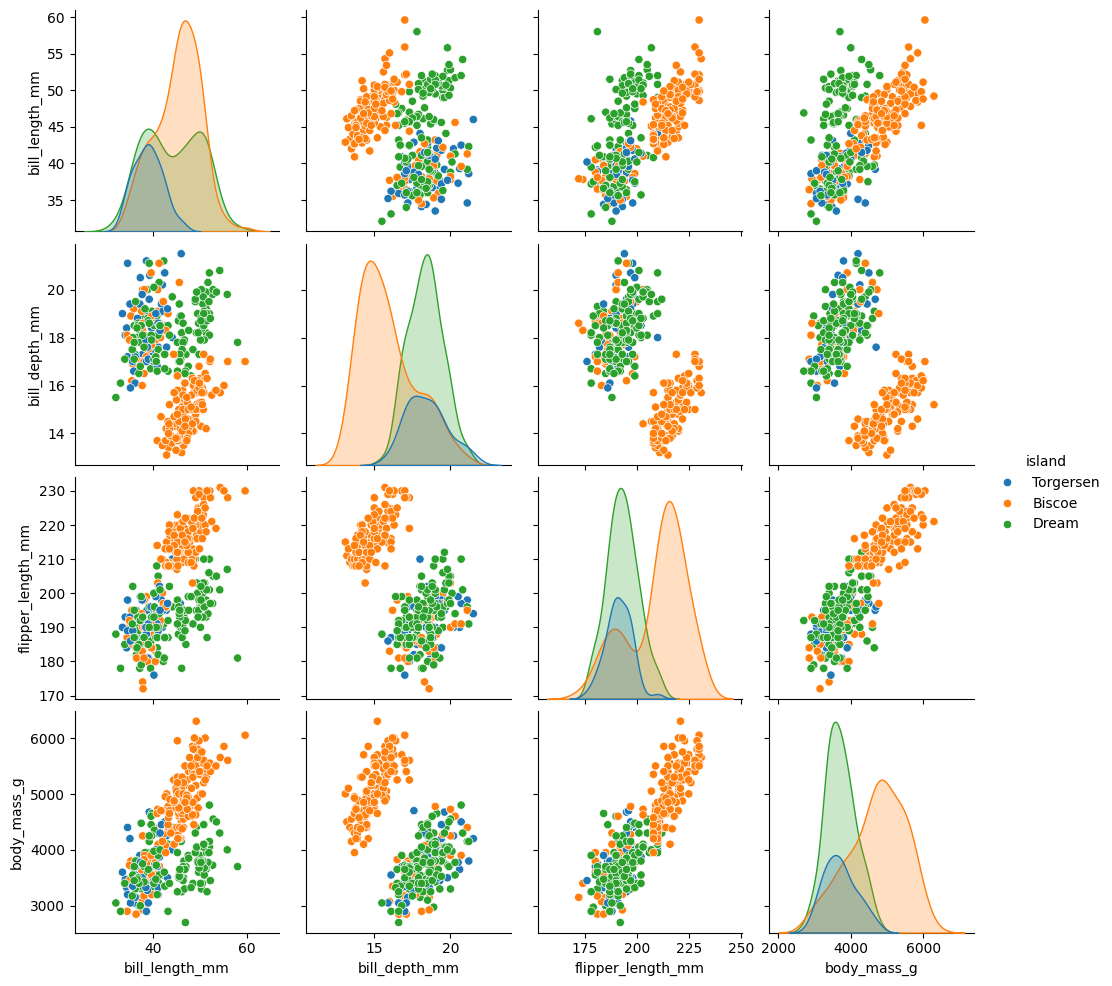

In [5]:
# Pair plot using island as hue
sns.pairplot(penguins, hue = 'island')
plt.show()

#### some islands contain different mixtures of penguin species. Because different species have different body sizes and measurements, the island can appear strongly associated with the measurements

In [6]:
# Number of penguins on each island
penguins['island'].value_counts()

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

#### Torgersen is clearly different in terms of the number of penguins.It has considerably fewer observations than Biscoe and Dream.

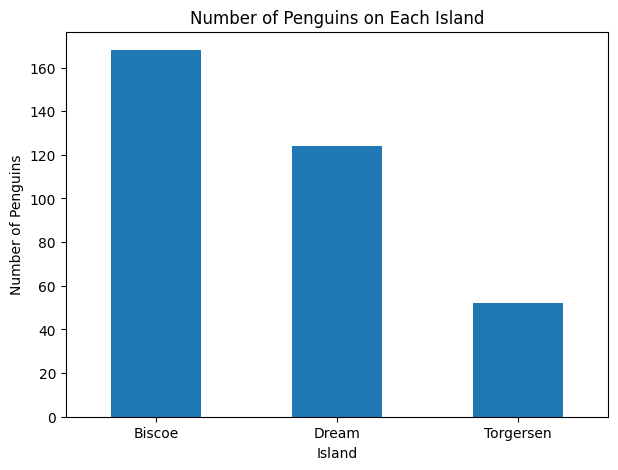

In [7]:
penguins['island'].value_counts().plot(kind = 'bar', figsize = (7,5))
plt.title("Number of Penguins on Each Island")
plt.xlabel("Island")
plt.ylabel("Number of Penguins")
plt.xticks(rotation=0)
plt.show()

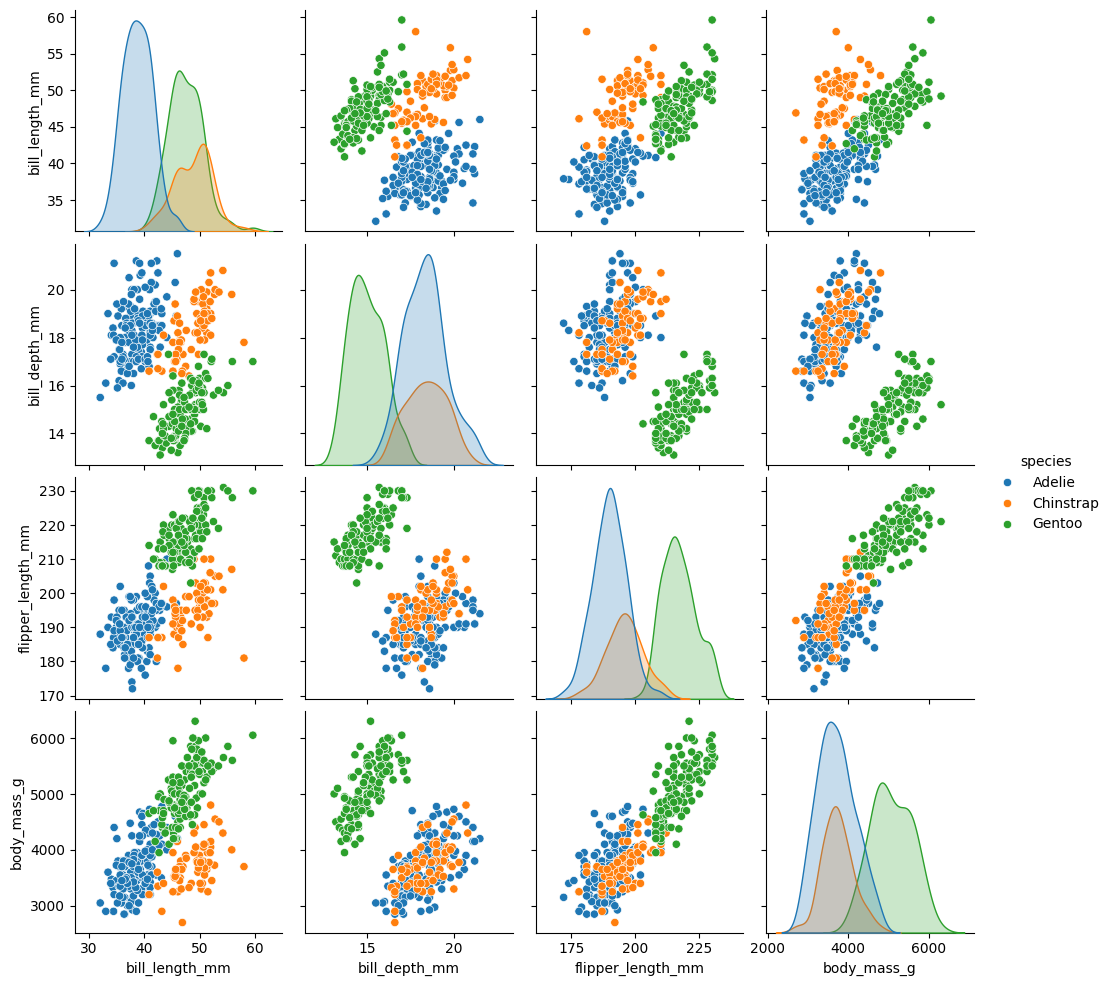

In [8]:
# Pair plot using species as hue
sns.pairplot(penguins, hue = 'species')
plt.show()

#### Gentoo penguins tend to have longer flippers ,greater body mass
#### Adelie penguins tend to have shorter flippers and lower body mass
#### Chinstrap penguins have distinctive bill measurements

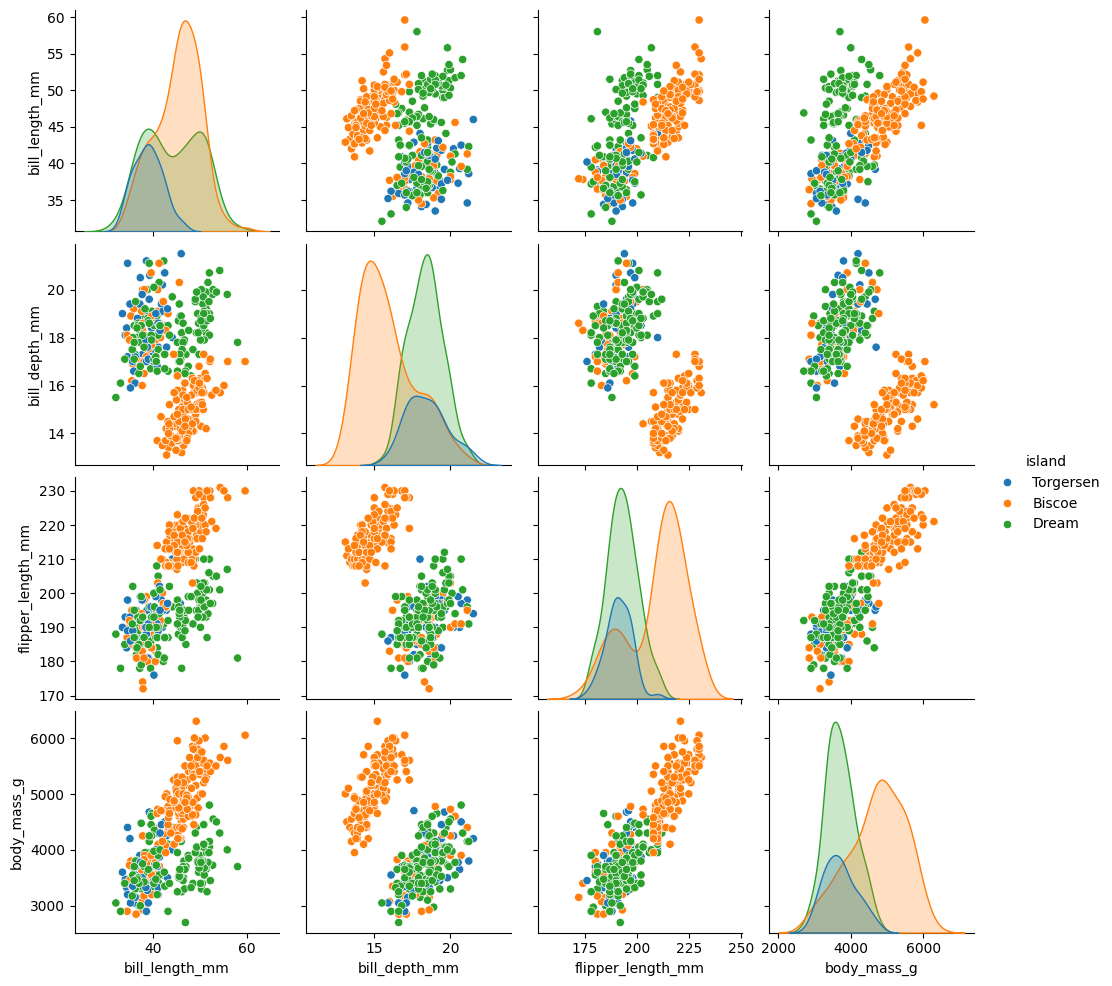

In [9]:
# Visualize how island and species differs using pair plots
sns.pairplot(penguins, hue = 'island')
plt.show()

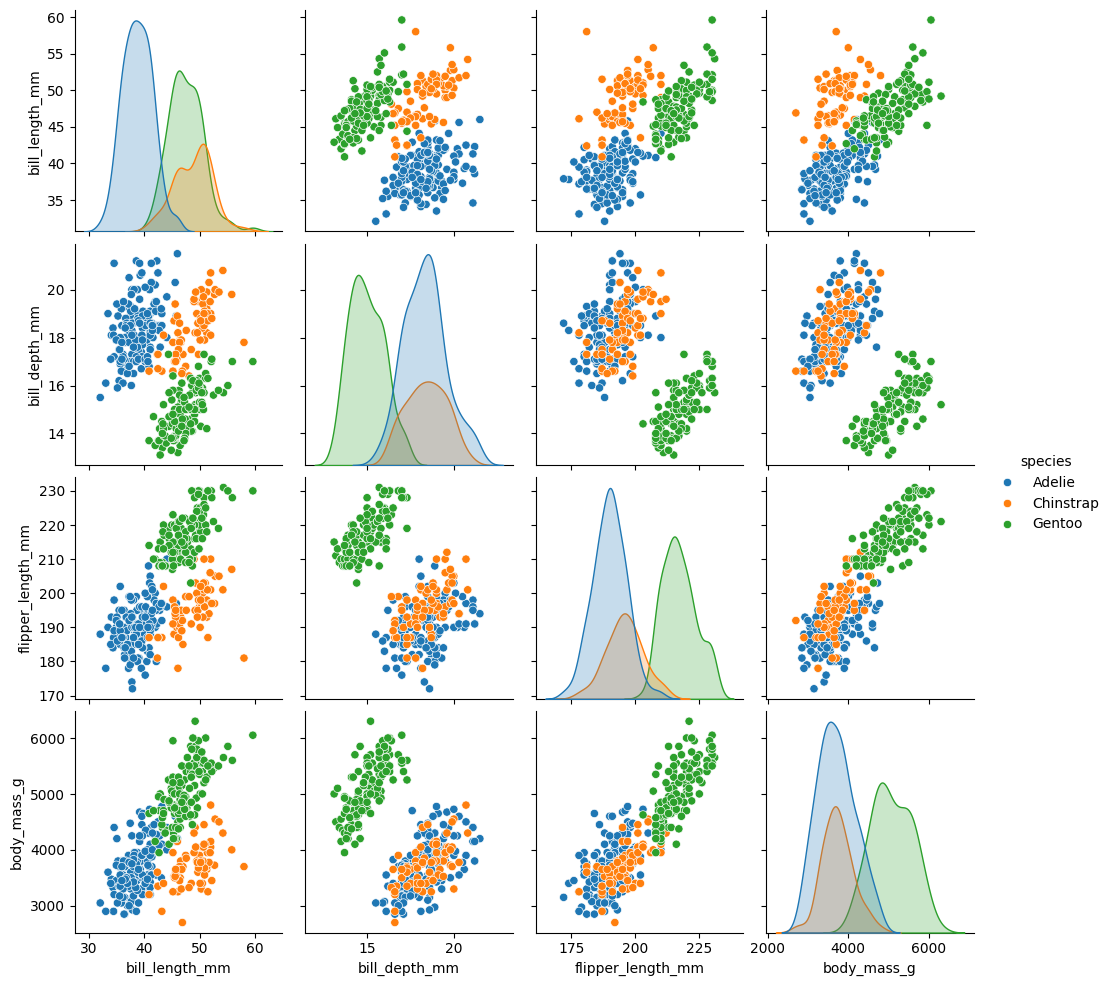

In [10]:
sns.pairplot(penguins, hue="species")
plt.show()

#### Generally species give clear distribution
#### Body Mass, Flipper Length, Bill Lenght, Bill Depth are strongly related to the species
#### Island is also useful, but part of its apparent effect comes from the fact that different species occur on different islands.
#### For example, Gentoo are associated with Biscoe, while Chinstrap are associated with Dream.   

In [11]:
# How does sex affect the result?
penguins['sex'].value_counts()


sex
Male      168
Female    165
Name: count, dtype: int64

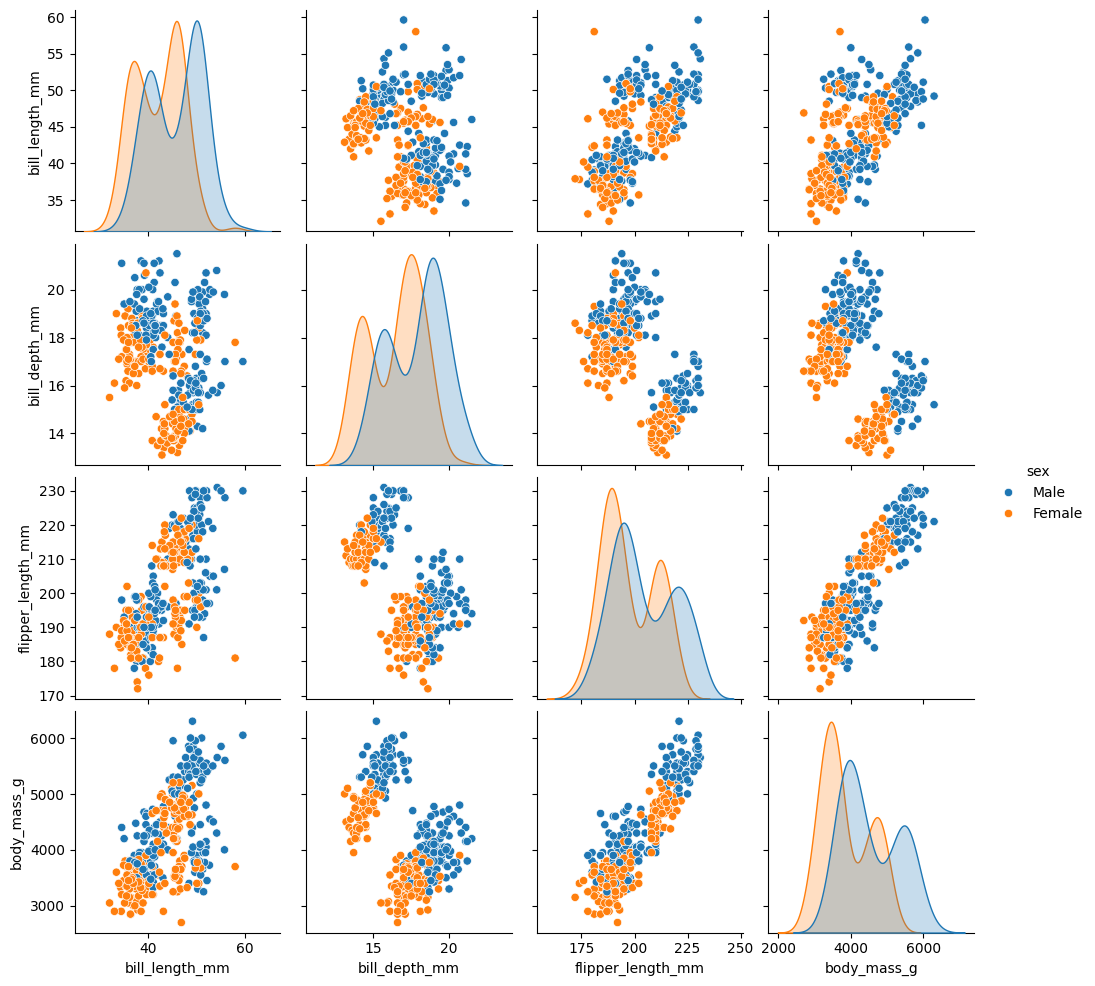

In [12]:
sns.pairplot(penguins, hue = 'sex')
plt.show()

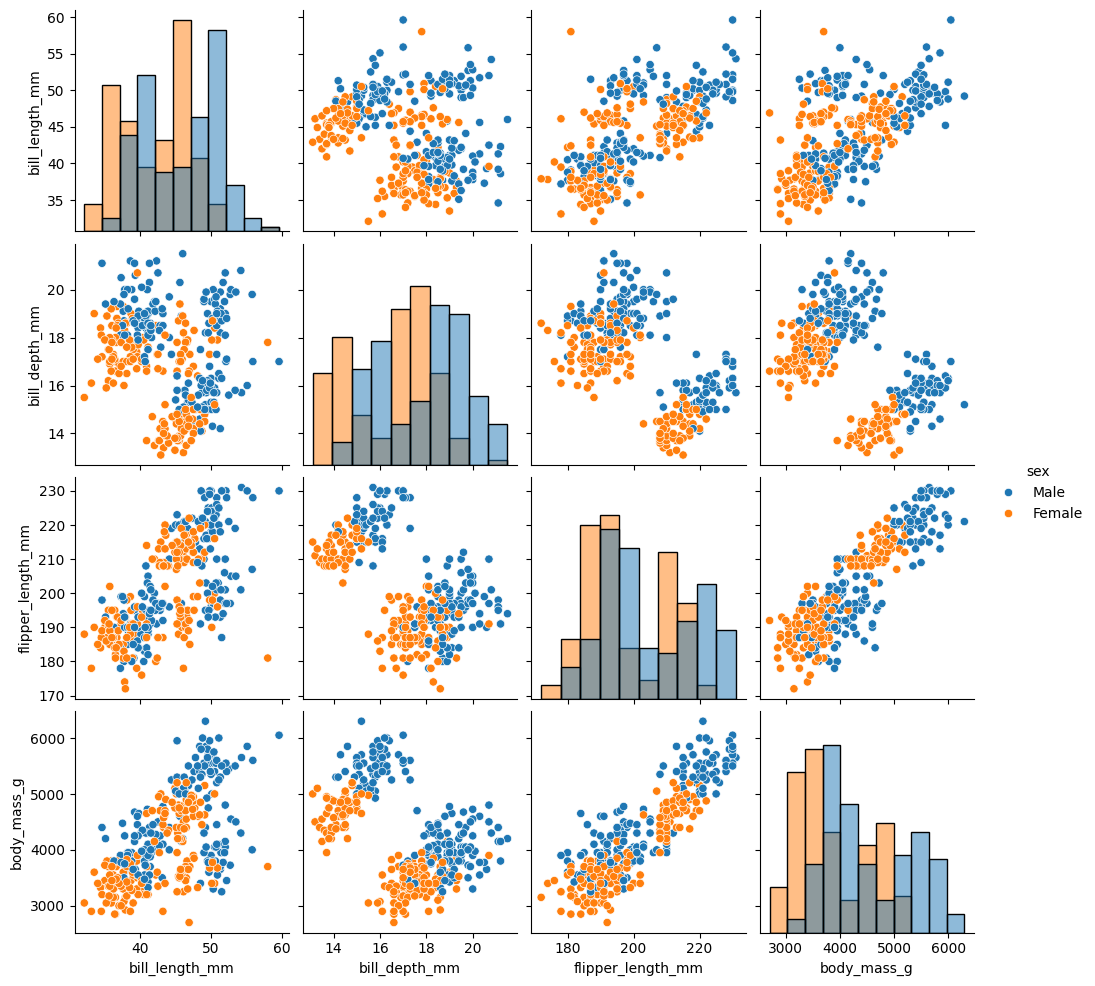

In [13]:
sns.pairplot(penguins, hue = 'sex', diag_kind = 'hist')
plt.show()

#### Male penguins tend to be larger and heavier than female penguins.

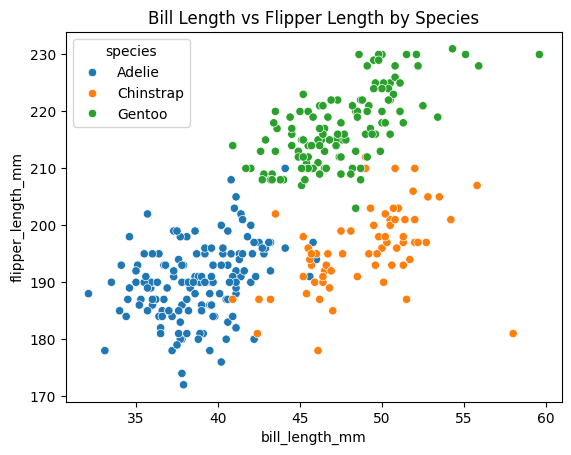

In [14]:
#Scatter plot: bill length vs flipper length using species as hue
sns.scatterplot(data = penguins, x = 'bill_length_mm', y = 'flipper_length_mm', hue = 'species')
plt.title("Bill Length vs Flipper Length by Species")
plt.show()

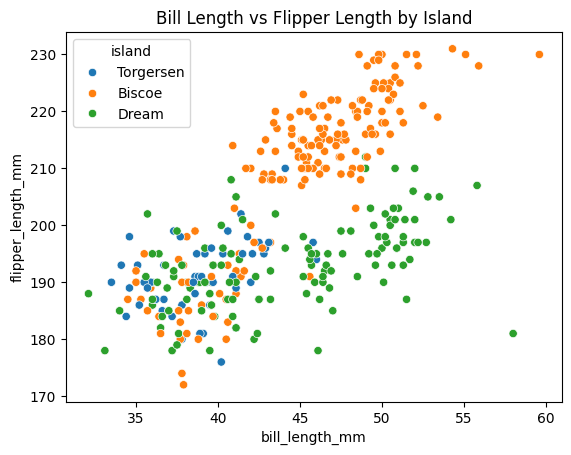

In [15]:
# The same comparison with getting "island" as hue
sns.scatterplot(data = penguins, x = 'bill_length_mm', y = 'flipper_length_mm', hue = 'island')
plt.title("Bill Length vs Flipper Length by Island")
plt.show()

#### The Species provide more clear result
#### The island plot also shows differences, but it doesn't separate the physical measurements as cleanly

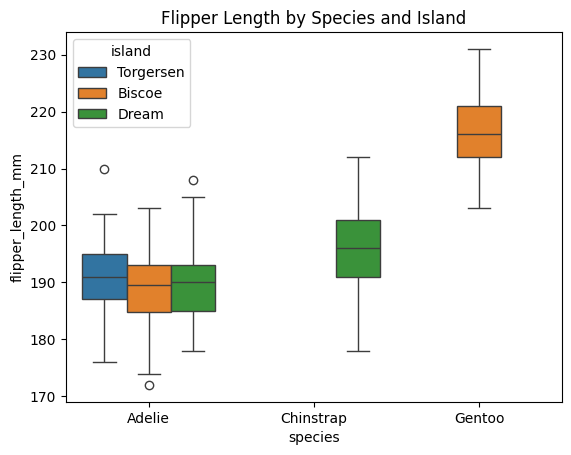

In [16]:
# We can use Box Plot to investigate the flipper_length_mm, bill_length_mm, body_mass_g with x = species and hue = island

#Flipper_length_mm
sns.boxplot(data = penguins, x = 'species', y = 'flipper_length_mm', hue = 'island')
plt.title("Flipper Length by Species and Island")
plt.show()

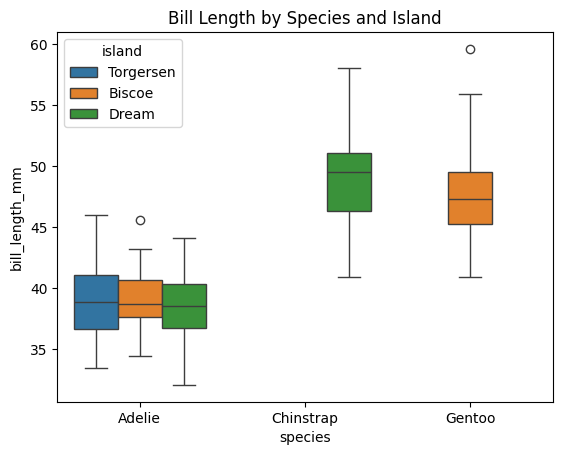

In [17]:
# Bill_length
sns.boxplot(data = penguins, x = 'species', y = 'bill_length_mm', hue = 'island')
plt.title("Bill Length by Species and Island")
plt.show()

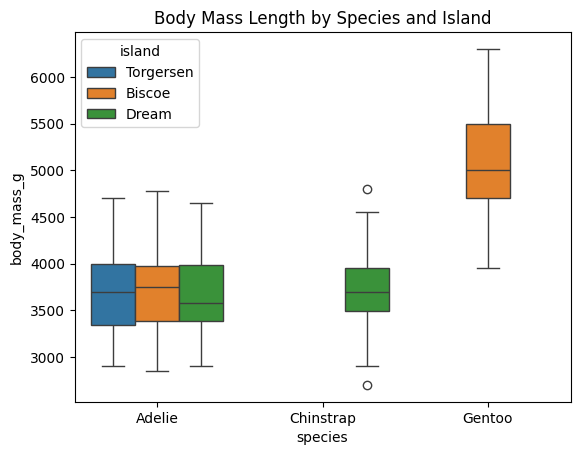

In [18]:
# Body Mass
sns.boxplot(data = penguins, x = 'species', y = 'body_mass_g', hue = 'island')
plt.title("Body Mass Length by Species and Island")
plt.show()

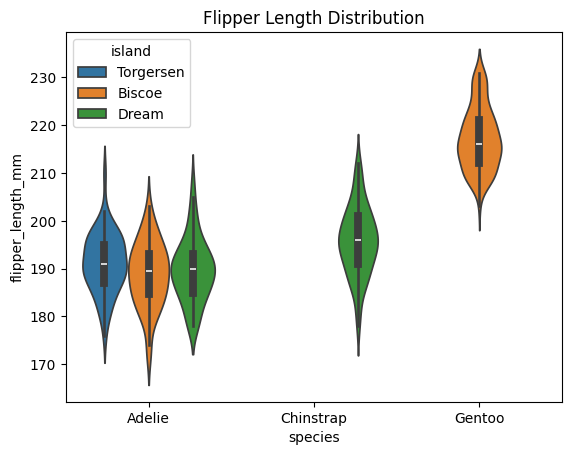

In [19]:
# We can use Violin Plot to investigate the flipper_length_mm, bill_length_mm, body_mass_g with x = species and hue = island
# FLipper Length
sns.violinplot(data = penguins, x = 'species', y = 'flipper_length_mm', hue = 'island')
plt.title("Flipper Length Distribution")
plt.show()

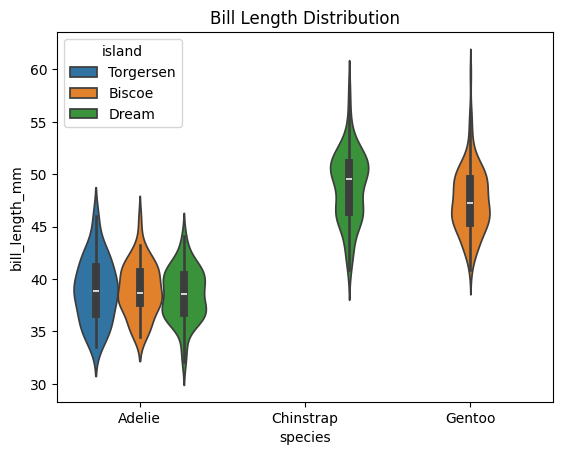

In [20]:
# Bill Length
sns.violinplot(data = penguins, x = 'species', y = 'bill_length_mm', hue = 'island')
plt.title("Bill Length Distribution")
plt.show()

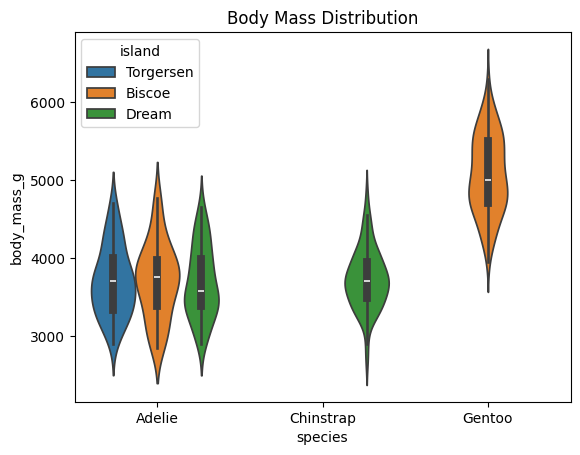

In [21]:
# BOdy Mass
sns.violinplot(data = penguins, x = 'species', y = 'body_mass_g', hue = 'island')
plt.title("Body Mass Distribution")
plt.show()

### Overall Conclusion
#### penguin species strongly influences physical measurements. The pair plots and scatter plots show clear clusters when species is used as hue.
#### island also reveals interesting patterns, but the effect is partly connected to the distribution of species across islands.
#### sex adds another layer: within species, males tend to be larger than females.

In [22]:
# Load the dataset of mpg 
mpg = sns.load_dataset('mpg')
mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [23]:
# Check missing values
mpg.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [24]:
# Clean the dataset - remove the missing values
mpg = mpg.dropna()
mpg.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [25]:
# Convert MPG to liters per 100 km
# This formular is taken from the ChatGpt
mpg['liters_per_100km'] = 235.215 / mpg['mpg']
mpg[['liters_per_100km']].head()

,liters_per_100km
0,13.067500
1,15.681000
2,13.067500
3,14.700938
4,13.836176


In [26]:
# Remove the original mpg and name columns
mpg = mpg.drop(columns = ['mpg', 'name'])
mpg.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,liters_per_100km
0,8,307.0,130.0,3504,12.0,70,usa,13.067500
1,8,350.0,165.0,3693,11.5,70,usa,15.681000
2,8,318.0,150.0,3436,11.0,70,usa,13.067500
3,8,304.0,150.0,3433,12.0,70,usa,14.700938
4,8,302.0,140.0,3449,10.5,70,usa,13.836176


In [27]:
# Create the correlation matrix
correlation_matrix = mpg.select_dtypes('number').corr()
print(correlation_matrix)

                  cylinders  displacement  horsepower    weight  acceleration  \
cylinders          1.000000      0.950823    0.842983  0.897527     -0.504683   
displacement       0.950823      1.000000    0.897257  0.932994     -0.543800   
horsepower         0.842983      0.897257    1.000000  0.864538     -0.689196   
weight             0.897527      0.932994    0.864538  1.000000     -0.416839   
acceleration      -0.504683     -0.543800   -0.689196 -0.416839      1.000000   
model_year        -0.345647     -0.369855   -0.416361 -0.309120      0.290316   
liters_per_100km   0.839385      0.866050    0.854809  0.885056     -0.456338   

                  model_year  liters_per_100km  
cylinders          -0.345647          0.839385  
displacement       -0.369855          0.866050  
horsepower         -0.416361          0.854809  
weight             -0.309120          0.885056  
acceleration        0.290316         -0.456338  
model_year          1.000000         -0.558255  
liters_p

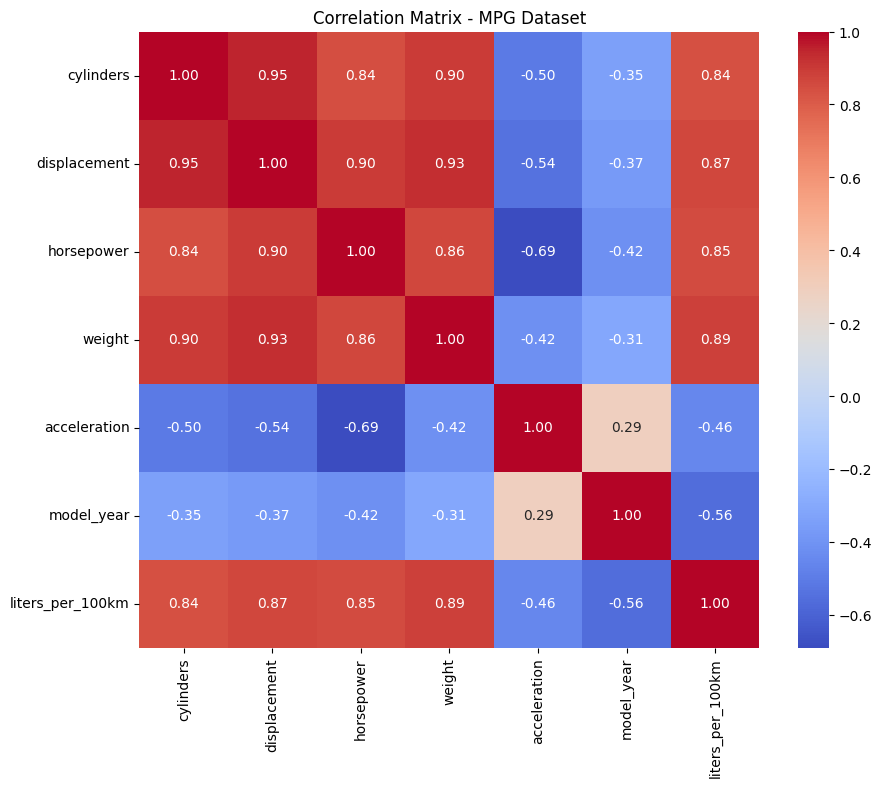

In [28]:
# Visualize the correclation
plt.figure(figsize = (10,8))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Matrix - MPG Dataset')
plt.show()

#### The two columns that generally have the weakest overall relationships with the other numerical variables are : 
##### ** Accelarion and model_year
#### Acceleration has relatively weak relationships with many of the other variables.
#### Model_year also has relatively weak direct correlations compared to the other measuring indexes

In [29]:
# Remove that two columns and calcuate the correlation again
mpg = mpg.drop(columns=["acceleration", "model_year"])
mpg.head()

,cylinders,displacement,horsepower,weight,origin,liters_per_100km
0,8,307.0,130.0,3504,usa,13.067500
1,8,350.0,165.0,3693,usa,15.681000
2,8,318.0,150.0,3436,usa,13.067500
3,8,304.0,150.0,3433,usa,14.700938
4,8,302.0,140.0,3449,usa,13.836176


In [30]:
# Create the correlation matrix again and visualize it
correlation_matrix = mpg.select_dtypes("number").corr()
print(correlation_matrix)

                  cylinders  displacement  horsepower    weight  \
cylinders          1.000000      0.950823    0.842983  0.897527   
displacement       0.950823      1.000000    0.897257  0.932994   
horsepower         0.842983      0.897257    1.000000  0.864538   
weight             0.897527      0.932994    0.864538  1.000000   
liters_per_100km   0.839385      0.866050    0.854809  0.885056   

                  liters_per_100km  
cylinders                 0.839385  
displacement              0.866050  
horsepower                0.854809  
weight                    0.885056  
liters_per_100km          1.000000  


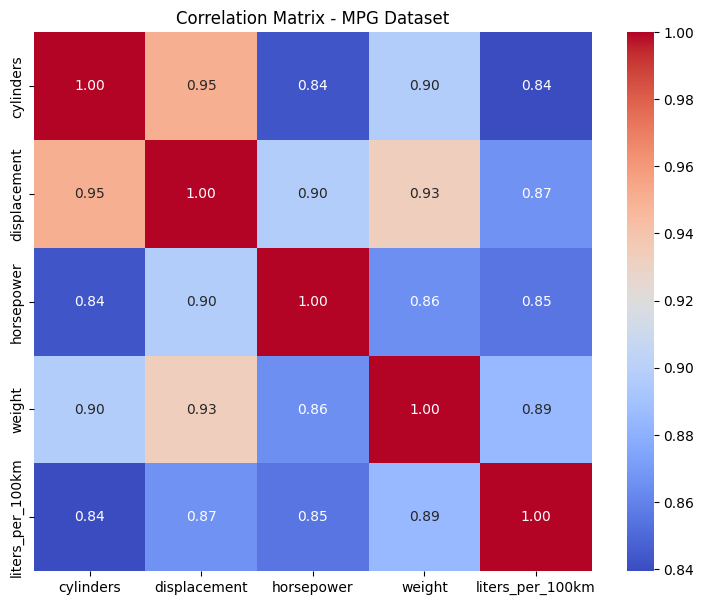

In [31]:
plt.figure(figsize = (9,7))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Matrix - MPG Dataset')
plt.show()

### We can see how these variables tightly combined with each other after removing the Accelarion and Model Year

In [32]:
# Cylinders vs horsepower vs displacement
# First we need to look at the overall corelation with these variables without liters_per_100km
variables = ["cylinders", "horsepower", "displacement"]
print(correlation_matrix[variables].abs().mean().sort_values(ascending=False))

displacement    0.929425
cylinders       0.906144
horsepower      0.891917
dtype: float64


In [33]:
print(correlation_matrix[["cylinders", "horsepower", "displacement", "liters_per_100km"]])

                  cylinders  horsepower  displacement  liters_per_100km
cylinders          1.000000    0.842983      0.950823          0.839385
displacement       0.950823    0.897257      1.000000          0.866050
horsepower         0.842983    1.000000      0.897257          0.854809
weight             0.897527    0.864538      0.932994          0.885056
liters_per_100km   0.839385    0.854809      0.866050          1.000000


#### Based on the correlation results the best choice is keep the displacement (Engine Size) and drop the horse power and cyliners variables from the dataset
#### Dispalcement shows higest positive relationship with the fuel consumption (liters_per_100km) than the other variables

In [34]:
# Remove those variables form the dataset
mpg = mpg.drop(columns = ['cylinders','horsepower'])
mpg.head()

,displacement,weight,origin,liters_per_100km
0,307.0,3504,usa,13.067500
1,350.0,3693,usa,15.681000
2,318.0,3436,usa,13.067500
3,304.0,3433,usa,14.700938
4,302.0,3449,usa,13.836176


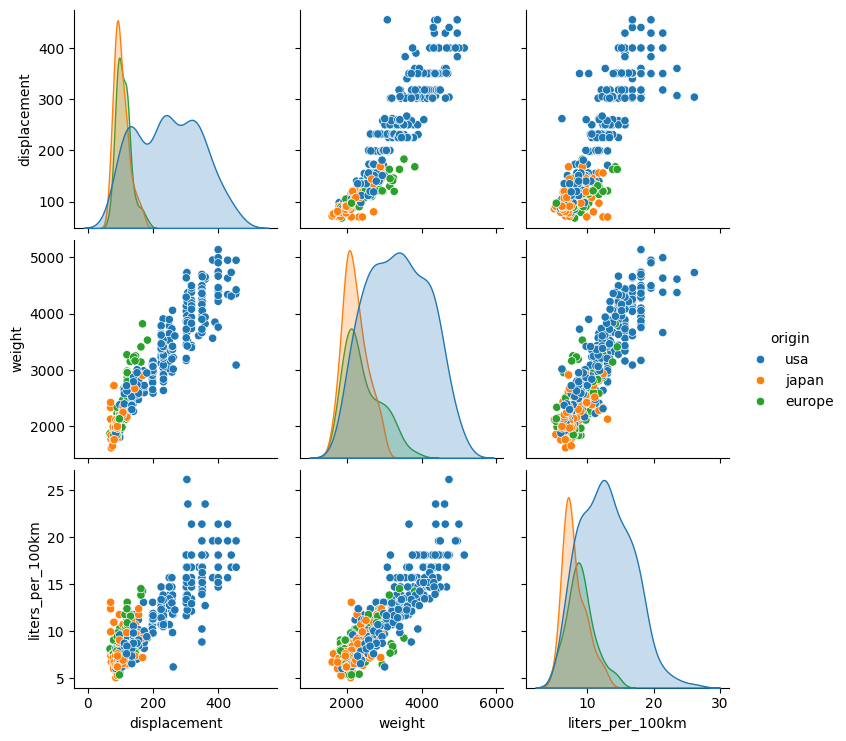

In [35]:
# Pair Plot with origin as the hue
sns.pairplot(mpg, hue = 'origin')
plt.show()

In [36]:
# Calculate which origin of vehicle has bigger fuel consumption
mpg.groupby('origin')['liters_per_100km'].mean().sort_values(ascending = False)


origin
usa       12.902829
europe     8.988951
japan      8.063175
Name: liters_per_100km, dtype: float64

#### So the USA originated vehicle has big fuel consumption and low fuel efficency

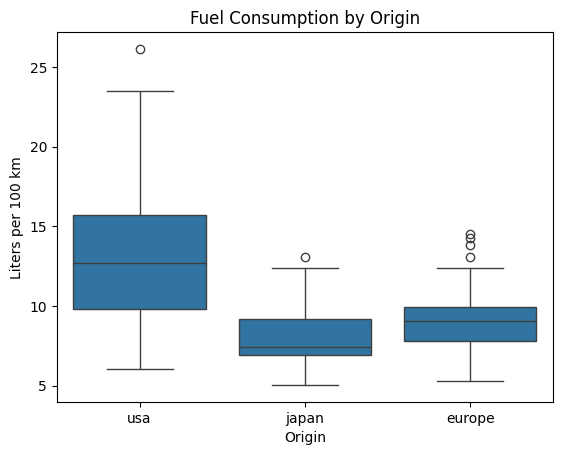

In [37]:
# Visualize the fuel consumption with origin using box plots and bar plots
sns.boxplot(data = mpg, x = 'origin', y = 'liters_per_100km')
plt.title("Fuel Consumption by Origin")
plt.xlabel("Origin")
plt.ylabel("Liters per 100 km")
plt.show()

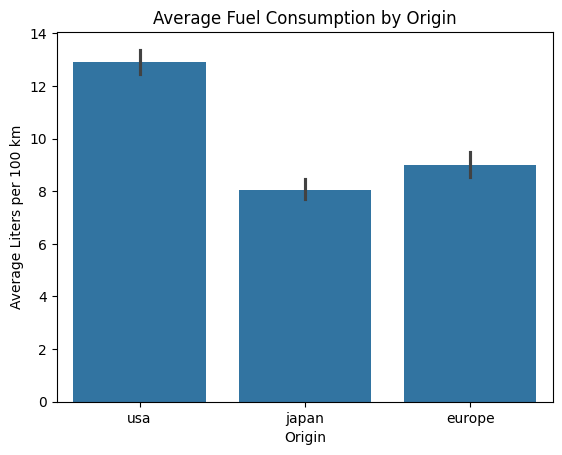

In [38]:
# Using bar plot
sns.barplot(data = mpg, x = 'origin', y = 'liters_per_100km')
plt.title("Average Fuel Consumption by Origin")
plt.xlabel("Origin")
plt.ylabel("Average Liters per 100 km")
plt.show()

In [39]:
# Analyse what features can cause for bigger fuel consumption
correlation_matrix['liters_per_100km'].sort_values(ascending = False)


liters_per_100km    1.000000
weight              0.885056
displacement        0.866050
horsepower          0.854809
cylinders           0.839385
Name: liters_per_100km, dtype: float64

#### A car that has :
##### heavier
##### more powerful
##### has a larger engine

#### will generally use more fuel.

In [40]:
# load the Dataset
df = pd.read_csv('groceries.csv')
df.head()

,Month,Rice,Wheat,Barley,Corn,Peanuts,Sugar,Coconut-oil,Palm-oil,Sunflower-oil,Chicken,Beef,Pork,Fish,Tea,Coffee
0,Oct-90,0.28,0.11,0.09,0.10,2.12,0.0049,0.28,0.29,0.58,0.0236,0.0571,2.5051,6.35,1.60,1.24
1,Nov-90,0.27,0.11,0.09,0.10,2.11,0.0049,0.34,0.33,0.56,0.0236,0.0558,2.4414,6.46,1.58,1.22
2,Dec-90,0.26,0.11,0.09,0.10,2.00,0.0046,0.32,0.35,0.55,0.0231,0.0562,2.3479,6.50,1.52,1.24
3,Jan-91,0.30,0.11,0.09,0.11,1.85,0.0042,0.34,0.35,0.57,0.0231,0.0571,2.6495,6.34,1.55,1.16
4,Feb-91,0.33,0.11,0.09,0.11,1.79,0.0042,0.33,0.34,0.60,0.0238,0.0602,2.3517,6.41,1.48,1.14


In [41]:
# Check the missing values
print(df.isna().sum())

Month              0
Rice               0
Wheat              0
Barley             0
Corn               0
Peanuts            0
Sugar              0
Coconut-oil        0
Palm-oil           0
Sunflower-oil    141
Chicken            0
Beef               0
Pork              39
Fish              39
Tea                0
Coffee             0
dtype: int64


In [42]:
# Fill the missing values using average(mean) of that columns
df.fillna({
    'Sunflower-oil': df['Sunflower-oil'].mean(),
    'Pork': df['Pork'].mean(),
    'Fish':df['Fish'].mean()
},inplace = True)

df.isna().sum()

Month            0
Rice             0
Wheat            0
Barley           0
Corn             0
Peanuts          0
Sugar            0
Coconut-oil      0
Palm-oil         0
Sunflower-oil    0
Chicken          0
Beef             0
Pork             0
Fish             0
Tea              0
Coffee           0
dtype: int64

In [43]:
# Split month column in to month and full year
# Examples refers with the help of AI, how to do this
parsed = pd.to_datetime(df['Month'], format = '%b-%y')

# Full month with numbers(1-12) and full year
df['Month_num'] = parsed.dt.month
df['Year'] = parsed.dt.year

df.head()



,Month,Rice,Wheat,Barley,Corn,Peanuts,Sugar,Coconut-oil,Palm-oil,Sunflower-oil,Chicken,Beef,Pork,Fish,Tea,Coffee,Month_num,Year
0,Oct-90,0.28,0.11,0.09,0.10,2.12,0.0049,0.28,0.29,0.58,0.0236,0.0571,2.5051,6.35,1.60,1.24,10,1990
1,Nov-90,0.27,0.11,0.09,0.10,2.11,0.0049,0.34,0.33,0.56,0.0236,0.0558,2.4414,6.46,1.58,1.22,11,1990
2,Dec-90,0.26,0.11,0.09,0.10,2.00,0.0046,0.32,0.35,0.55,0.0231,0.0562,2.3479,6.50,1.52,1.24,12,1990
3,Jan-91,0.30,0.11,0.09,0.11,1.85,0.0042,0.34,0.35,0.57,0.0231,0.0571,2.6495,6.34,1.55,1.16,1,1991
4,Feb-91,0.33,0.11,0.09,0.11,1.79,0.0042,0.33,0.34,0.60,0.0238,0.0602,2.3517,6.41,1.48,1.14,2,1991


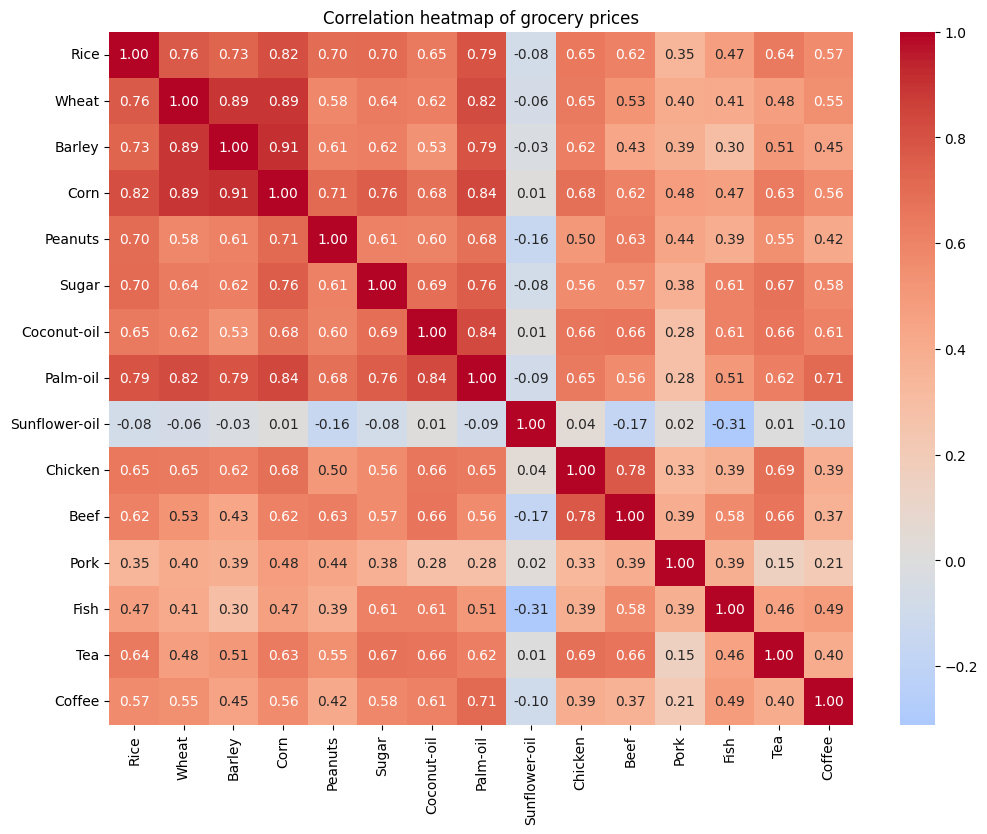

In [44]:
# Calculate the correlation
# Price columns
price_columns = ['Rice','Wheat','Barley','Corn','Peanuts','Sugar','Coconut-oil', 'Palm-oil','Sunflower-oil','Chicken','Beef','Pork','Fish','Tea','Coffee']

correlation_matrix = df[price_columns].corr()

# Visualize it
plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation heatmap of grocery prices')
plt.show()

#### Sunflowe-oil shows completely an opposite behaviour with the other grocery items. Because its price has a much weaker relationship with the prices of the other groceries.

#### Wheat, Barley, Corn, Rice, Coconut-oil and Palm-oil cluster together show strongly coreelation each other

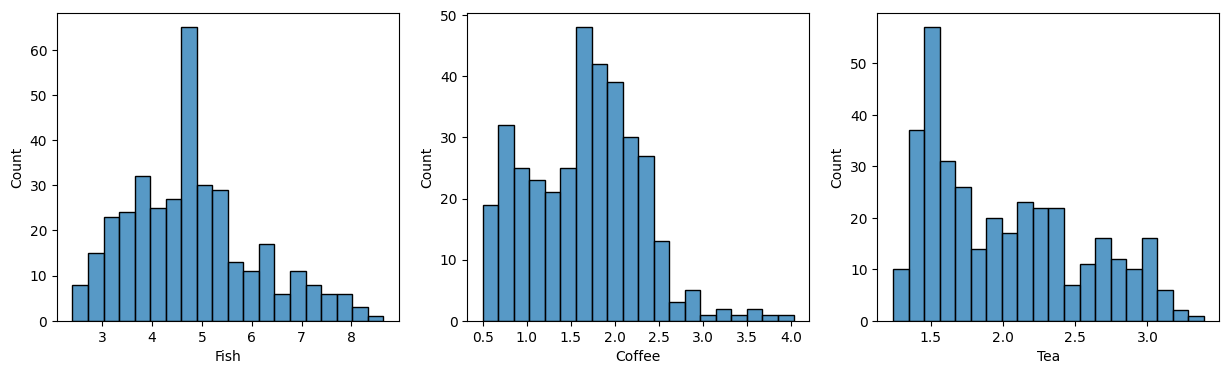

In [45]:
# Histograms for Fish, Coffee and Tea
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['Fish'], bins=20, ax=axes[0])
sns.histplot(df['Coffee'], bins=20, ax=axes[1])
sns.histplot(df['Tea'], bins=20, ax=axes[2])
plt.show()

In [46]:
# To analyse which prices have been historically typical for these products
# we can calculate mean value of the each product's price - we can use describe() for quick statsitical calculation
df[['Fish', 'Coffee', 'Tea']].describe()

,Fish,Coffee,Tea
count,360.000000,360.000000,360.000000
mean,4.806947,1.647556,2.010944
std,1.278366,0.632771,0.534095
min,2.400000,0.500000,1.240000
25%,3.860000,1.120000,1.537500
50%,4.806947,1.685000,1.910000
75%,5.432500,2.050000,2.392500
max,8.640000,4.030000,3.390000


#### Fish generally had the highest price of these three products. Its typical price was around 4.8.

#### Coffee had a typical price of around 1.6–1.7.

#### Tea had a typical price of around 1.9–2.0.

In [47]:
# Find the year when Corn had a notable price peak
prices_by_the_year = df.groupby('Year')['Corn'].mean()
prices_by_the_year

Year
1990    0.100000
1991    0.109167
1992    0.104167
1993    0.101667
1994    0.108333
1995    0.124167
1996    0.166667
1997    0.116667
1998    0.102500
1999    0.090833
2000    0.090833
2001    0.089167
2002    0.099167
2003    0.107500
2004    0.110833
2005    0.100000
2006    0.121667
2007    0.163333
2008    0.223333
2009    0.164167
2010    0.186667
2011    0.290833
2012    0.297500
2013    0.260000
2014    0.192500
2015    0.169167
2016    0.158333
2017    0.155833
2018    0.165000
2019    0.171667
2020    0.156667
Name: Corn, dtype: float64

In [48]:
# FInd the year with highest average price
highest_year = prices_by_the_year.idxmax()
highest_price = prices_by_the_year.max()

print("Highest year:", highest_year)
print("Average price:", highest_price)

Highest year: 2012
Average price: 0.29750000000000004


#### The highest yearly average for Corn occurs in 2012 with an average price of approximately 0.30

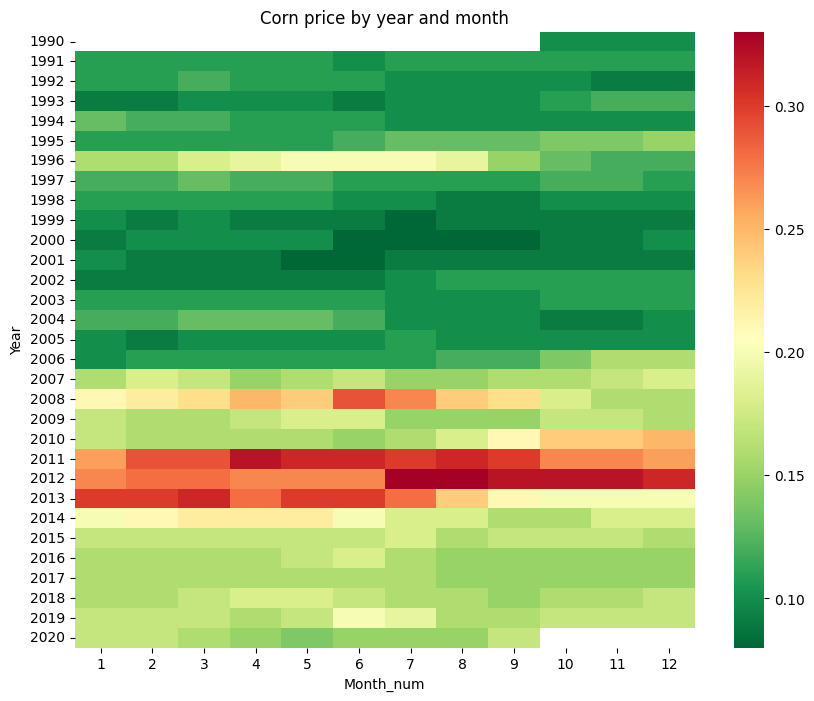

In [49]:
# Visualize it with pivot tables and Heat map
pivot = df.pivot_table(index='Year', columns='Month_num', values='Corn')

plt.figure(figsize=(10, 8))
sns.heatmap(pivot, cmap='RdYlGn_r')
plt.title('Corn price by year and month')
plt.show()

### Possible Historical Explanation with the help of Google and AI
##### There was a major 2012 drought in the United States, which severely affected agricultural production, particularly corn and other crops. This provides a plausible real-world explanation for the price increase.
##### The 2007–2008 global food-price crisis caused large increases in prices of several agricultural commodities, including grains such as rice and wheat.

In [50]:
# Load the dataset
df = pd.read_csv('mobilephones.csv')
df.head()

,Brand,BatteryCapacity,RAM,ScreenSize,Price
0,Apple,3095,6,6.10,999
1,Samsung,5000,12,6.80,1199
2,Xiaomi,5020,6,6.67,279
3,Apple,2815,4,6.10,799
4,Samsung,3300,8,6.70,999


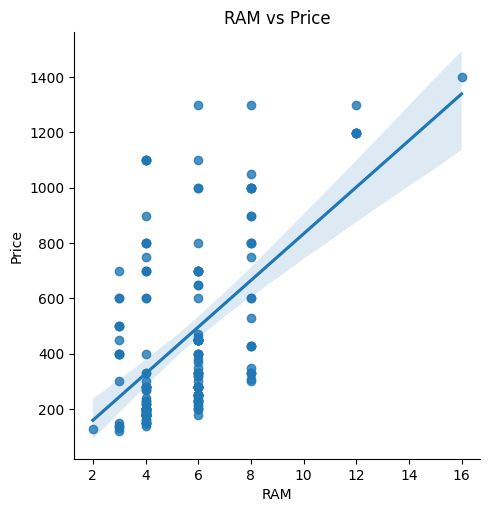

In [51]:
# Regression plot for RAM and Price, no hue
sns.lmplot(x = 'RAM', y = 'Price', data = df)
plt.title('RAM vs Price')
plt.show()


### The regression line slopes upwards, so there is a positive correlation between RAM and Price.
### Generally, phones with more RAM tend to have higher prices.

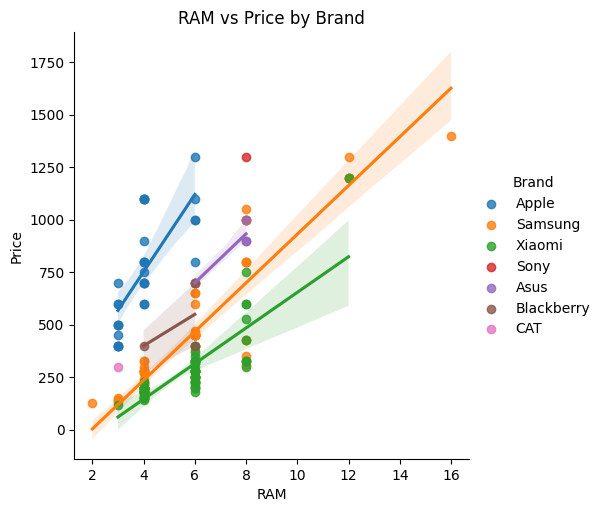

In [52]:
#Regression plot for RAM and Price, hue on Brand
sns.lmplot(x="RAM", y="Price", data=df, hue="Brand")

plt.title("RAM vs Price by Brand")
plt.show()

#### Compared with the plot without hue, we can see that Brand affects the relationship between RAM and Price.

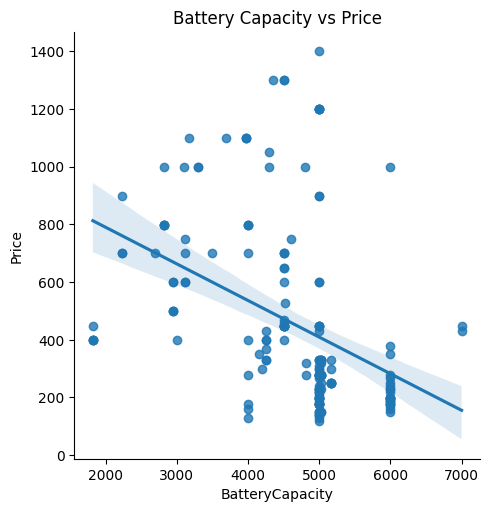

In [53]:
# Regression plot for BatteryCapacity and Price, no hue
sns.lmplot(x="BatteryCapacity", y="Price", data=df)

plt.title("Battery Capacity vs Price")
plt.show()

### The regression line slopes downwards, so there is a negative correlation.
### Phones with larger battery capacity do not necessarily have higher prices.

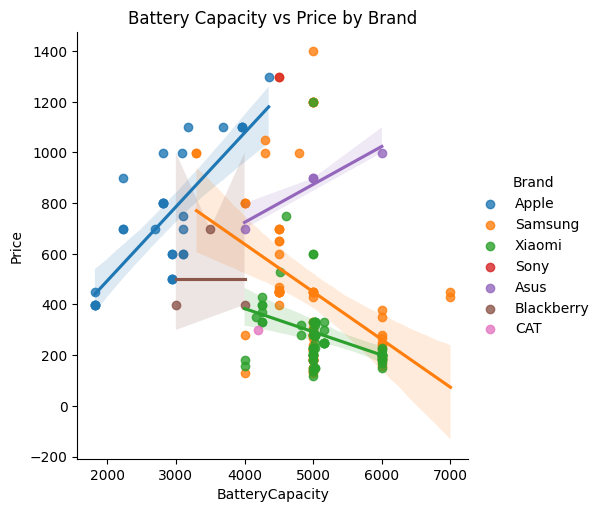

In [54]:
#Phones with larger battery capacity do not necessarily have higher prices.
sns.lmplot(x="BatteryCapacity", y="Price", data=df, hue="Brand")

plt.title("Battery Capacity vs Price by Brand")
plt.show()

### The relationship changes considerably when we compare with the Brand
- Apple: strong positive relationship
- Asus: very strong positive relationship
- Samsung: negative relationship
- Xiaomi: negative relationship
### So the Brand has an important effect on the relationship

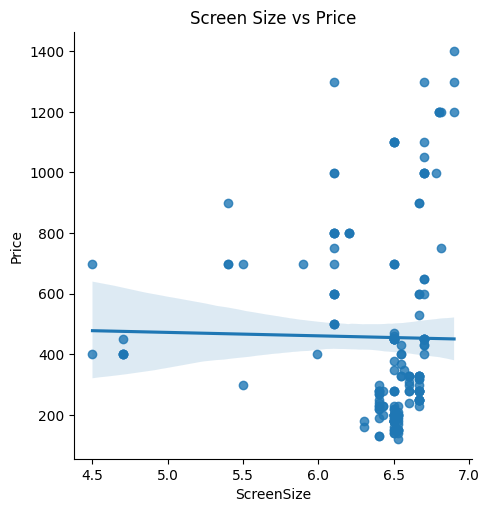

In [55]:
# ScreenSize and Price — without hue
sns.lmplot(x="ScreenSize", y="Price", data=df)

plt.title("Screen Size vs Price")
plt.show()

### The regression line is almost flat.
### Almost no linear correlation between ScreenSize and Price

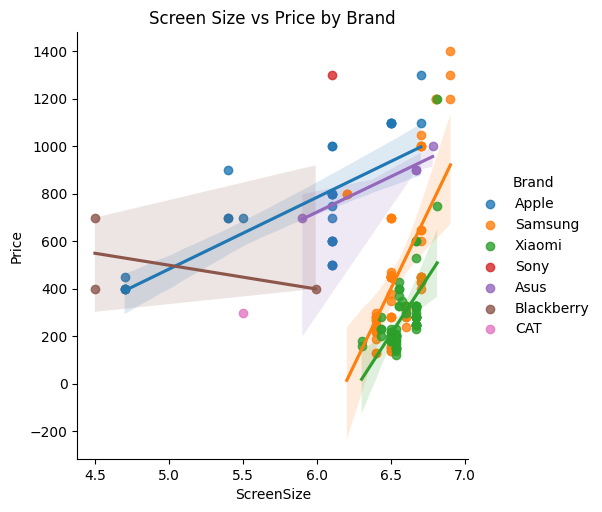

In [56]:
# ScreenSize and Price — with Brand
sns.lmplot(x="ScreenSize", y="Price", data=df, hue="Brand")

plt.title("Screen Size vs Price by Brand")
plt.show()

### Several brands show a positive relationship between ScreenSize and Price.
- Without hue: almost no correlation 
- With hue: several brands show positive correlations

In [57]:
# Load the processed dataset
df = pd.read_csv('processed_house_sales.csv')
df.head()

,saledate,type,bedrooms,avg_price
0,2007-02,house,3,290000.0
1,2007-02,house,4,525000.0
2,2007-03,house,3,319000.0
3,2007-03,house,4,380000.0
4,2007-04,house,3,399000.0


In [58]:
#Convert saledate to timestamp and sort it
df["saledate"] = pd.to_datetime(df["saledate"], dayfirst=True)
df = df.sort_values("saledate")
df.head()

,saledate,type,bedrooms,avg_price
0,2007-02-01,house,3,290000.0
1,2007-02-01,house,4,525000.0
2,2007-03-01,house,3,319000.0
3,2007-03-01,house,4,380000.0
4,2007-04-01,house,3,399000.0


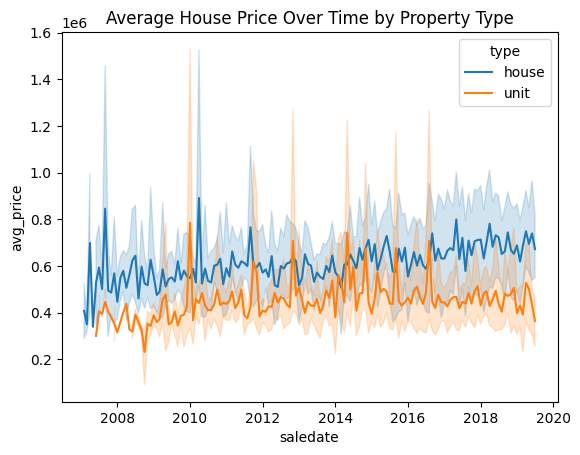

In [59]:
# Line plot: saledate vs avg_price, with hue = type
sns.lineplot(x="saledate", y="avg_price", hue="type", data=df)
plt.title("Average House Price Over Time by Property Type")
plt.show()

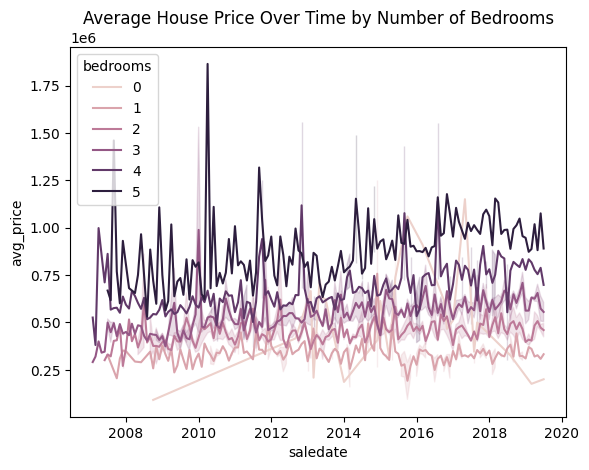

In [60]:
# Line plot: saledate vs avg_price, with hue = bedrooms
sns.lineplot(x="saledate", y="avg_price", hue="bedrooms", data=df)
plt.title("Average House Price Over Time by Number of Bedrooms")
plt.show()

## What overall trend can you see?
#### The overall trend shows that average house prices generally increased over time. There are some fluctuations and periods of decline, but the long-term trend is clearly upward.

## Study (Google / AI) the postcodes (raw_house_sales.csv) and research: which city do the postcodes most likely refer to?
#### By Refering the details given by the AI
#### The postcodes most likely refer to Canberra, Australia, in the Australian Capital Territory (ACT).

## Research (Google/AI) and find an explanation for the phenomenon happening in the city based on the line plots
#### By Refering the details given by the AI
#### The increase in Canberra house prices is related to changes in the housing market, including interest rates and demand for housing. The data also shows periods of slower growth or decline, which are consistent with changes in the Canberra housing market during these years.

In [61]:
# Convert raw data into summarized format
# Load the raw dataset
raw_df = pd.read_csv('raw_house_sales.csv')
raw_df.head()

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


In [62]:
# Convert the date
raw_df['datesold'] = pd.to_datetime(raw_df['datesold'])

# Create the month column
# We can calcualte the average price by the month later
raw_df['month'] = raw_df['datesold'].dt.to_period('M')
raw_df.head()

,datesold,postcode,price,propertyType,bedrooms,month
0,2007-02-07,2607,525000,house,4,2007-02
1,2007-02-27,2906,290000,house,3,2007-02
2,2007-03-07,2905,328000,house,3,2007-03
3,2007-03-09,2905,380000,house,4,2007-03
4,2007-03-21,2906,310000,house,3,2007-03


In [63]:
# Now calculate the average price for each month, property type and bedroom number.
proccessed_data = raw_df.groupby(["month", "propertyType", "bedrooms"])['price'].mean().reset_index()

# Rename the columns
proccessed_data = proccessed_data.rename(columns = {
    "month": "saledate",
    "propertyType": "type",
    "price": "avg_price"
})
# Save the dataset
proccessed_data.to_csv('processed_house_sales.csv', index = False)

proccessed_data.head()




,saledate,type,bedrooms,avg_price
0,2007-02,house,3,290000.0
1,2007-02,house,4,525000.0
2,2007-03,house,3,319000.0
3,2007-03,house,4,380000.0
4,2007-04,house,3,399000.0


In [64]:
# Load the Titanic dataset
titanic_df = sns.load_dataset('titanic')
titanic_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [65]:
# Check the survival by sex
titanic_df.groupby('sex')['survived'].mean()


sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

### Approximately :
- 74% of females survived
- 19% of males survived

In [66]:
# Check survival by passenger class
titanic_df.groupby('class')['survived'].mean()

class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64

- 1st class: about 63% survived
- 2nd class: about 47% survived
- 3rd class: about 24% survived

### Therefore, first-class passengers were more likely to survive, while third-class passengers had the lowest survival rate

In [67]:
# Check survival by sex AND class
print(titanic_df.groupby(["sex", "class"])["survived"].mean())


sex     class 
female  First     0.968085
        Second    0.921053
        Third     0.500000
male    First     0.368852
        Second    0.157407
        Third     0.135447
Name: survived, dtype: float64


In [68]:
# Check average age of survival basd on gender
print(titanic_df.groupby(["survived", "sex"])["age"].mean())

survived  sex   
0         female    25.046875
          male      31.618056
1         female    28.847716
          male      27.276022
Name: age, dtype: float64


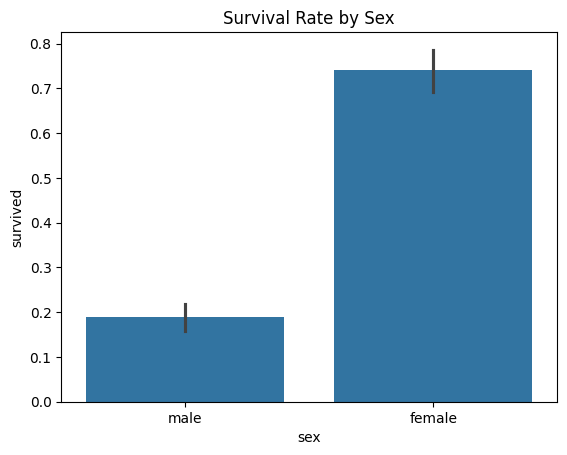

In [69]:
# Visualize them via Bar-plots
sns.barplot(x="sex", y="survived", data = titanic_df)
plt.title("Survival Rate by Sex")
plt.show()

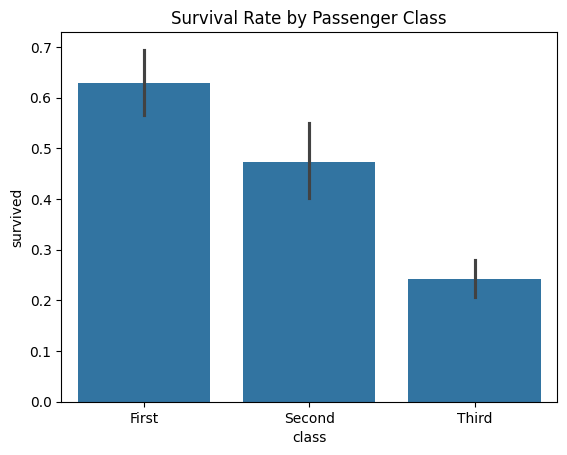

In [70]:
sns.barplot(x="class", y="survived", data = titanic_df)
plt.title("Survival Rate by Passenger Class")
plt.show()

## Conclusions
- The typical person who survived the Titanic was more likely to be female and from a higher passenger class, especially first or second class. 
- Female passengers had a much higher survival rate than male passengers. 
- First-class passengers also had a much higher survival rate than third-class passengers. 
- Age also had an influence, with children generally having better survival chances than adult men. 
- Overall, sex and passenger class appear to be two of the strongest features associated with survival.

In [71]:
# Load the dataset
df = pd.read_csv('steel_chemical_measurements.csv')
df.head()

,HEATID,POSITIONROW,DATETIME,VALC,VALSI,VALMN,VALP,VALS,VALCU,VALCR,VALMO,VALNI
0,6F0020,1,2016-01-01 19:59:00,"0,2312","0,2449","1,2652","0,0076","0,0147","0,2072","0,0726","0,0194","0,1323"
1,6F0021,1,2016-01-01 20:59:00,"0,2507","0,2687","1,2916","0,0055","0,0204","0,2045","0,0747","0,0206","0,1326"
2,6F0022,1,2016-01-01 21:53:00,"0,234","0,2276","1,1963","0,0056","0,0193","0,1898","0,0695","0,0203","0,1218"
3,6F0023,1,2016-01-01 23:27:00,"0,3652","0,2154","0,7934","0,0078","0,025","0,2154","0,0956","0,0342","0,2051"
4,6F0024,1,2016-01-02 00:32:00,"0,374","0,1932","0,7948","0,0071","0,0202","0,2191","0,1029","0,0267","0,1534"


In [72]:
# The values are shown here with "," So we need to use "." instead of  ","
chemical_columns = ["VALC", "VALSI", "VALMN", "VALP", "VALS","VALCU", "VALCR", "VALMO", "VALNI"]

# We use for-loop for this
for column in chemical_columns:
    df[column] = pd.to_numeric(
        df[column].astype(str).str.replace(",", ".")
    )


df.head()




,HEATID,POSITIONROW,DATETIME,VALC,VALSI,VALMN,VALP,VALS,VALCU,VALCR,VALMO,VALNI
0,6F0020,1,2016-01-01 19:59:00,0.2312,0.2449,1.2652,0.0076,0.0147,0.2072,0.0726,0.0194,0.1323
1,6F0021,1,2016-01-01 20:59:00,0.2507,0.2687,1.2916,0.0055,0.0204,0.2045,0.0747,0.0206,0.1326
2,6F0022,1,2016-01-01 21:53:00,0.2340,0.2276,1.1963,0.0056,0.0193,0.1898,0.0695,0.0203,0.1218
3,6F0023,1,2016-01-01 23:27:00,0.3652,0.2154,0.7934,0.0078,0.0250,0.2154,0.0956,0.0342,0.2051
4,6F0024,1,2016-01-02 00:32:00,0.3740,0.1932,0.7948,0.0071,0.0202,0.2191,0.1029,0.0267,0.1534


In [73]:
# Convert the date column
df['DATETIME'] = pd.to_datetime(df['DATETIME'])
df.head()

,HEATID,POSITIONROW,DATETIME,VALC,VALSI,VALMN,VALP,VALS,VALCU,VALCR,VALMO,VALNI
0,6F0020,1,2016-01-01 19:59:00,0.2312,0.2449,1.2652,0.0076,0.0147,0.2072,0.0726,0.0194,0.1323
1,6F0021,1,2016-01-01 20:59:00,0.2507,0.2687,1.2916,0.0055,0.0204,0.2045,0.0747,0.0206,0.1326
2,6F0022,1,2016-01-01 21:53:00,0.2340,0.2276,1.1963,0.0056,0.0193,0.1898,0.0695,0.0203,0.1218
3,6F0023,1,2016-01-01 23:27:00,0.3652,0.2154,0.7934,0.0078,0.0250,0.2154,0.0956,0.0342,0.2051
4,6F0024,1,2016-01-02 00:32:00,0.3740,0.1932,0.7948,0.0071,0.0202,0.2191,0.1029,0.0267,0.1534


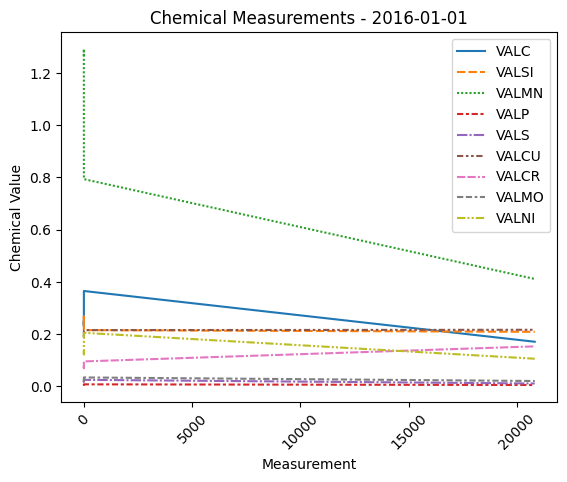

In [74]:
# Visualize a multiline plot for the date "2016-01-01"
# Analyse Which chemical measurement has a sharp decline in this timestamp
date = df[df['DATETIME'].dt.date == pd.Timestamp('2016-01-01').date()]

# Create a multiline plot
sns.lineplot(data = date[chemical_columns])
plt.title("Chemical Measurements - 2016-01-01")
plt.xlabel("Measurement")
plt.ylabel("Chemical Value")
plt.xticks(rotation=45)
plt.show()


### On 2016-01-01, VALMN shows the sharpest decline among the chemical measurements.

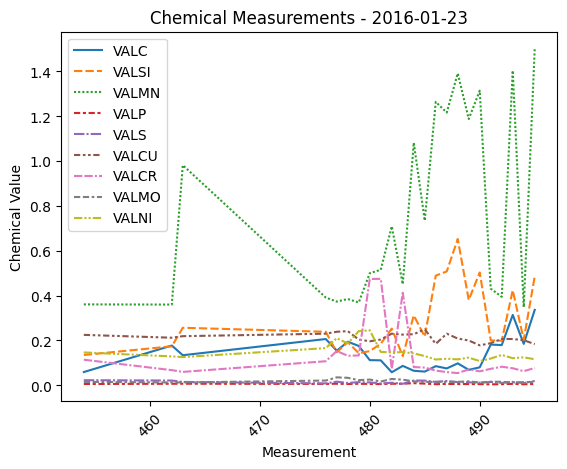

In [75]:
# Visualize a multiline plot for the date "2016-01-23"
# Analyse Which four chemical measurements fluctuate the most in this timestamp
date = df[df['DATETIME'].dt.date == pd.Timestamp('2016-01-23').date()]

# Create a multiline plot
sns.lineplot(data = date[chemical_columns])
plt.title("Chemical Measurements - 2016-01-23")
plt.xlabel("Measurement")
plt.ylabel("Chemical Value")
plt.xticks(rotation=45)
plt.show()


### On 2016-01-23, VALMN, VALSI, VALCR and VALC fluctuate the most. VALMN shows the largest fluctuations.

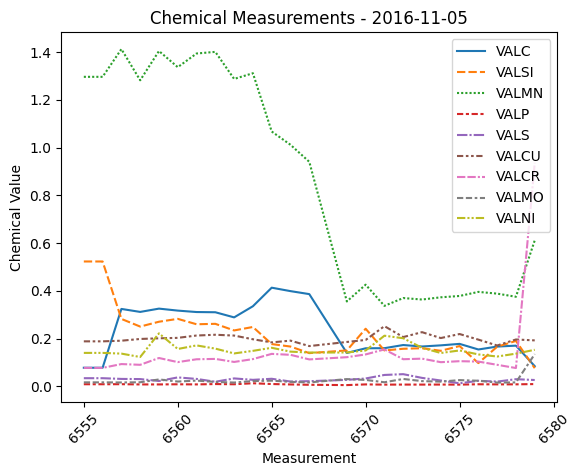

In [76]:
# Visualize a multiline plot for the date "2016-11-05"
# Which chemical measurement has a sharp increase in this timestamp
date = df[df['DATETIME'].dt.date == pd.Timestamp('2016-11-05').date()]

# Create a multiline plot
sns.lineplot(data = date[chemical_columns])
plt.title("Chemical Measurements - 2016-11-05")
plt.xlabel("Measurement")
plt.ylabel("Chemical Value")
plt.xticks(rotation=45)
plt.show()


### On 2016-11-05, VALCR shows the sharpest increase among the chemical measurements.

In [77]:
# Find the dates with the largest changes.
df['VALMN_Change'] = df['VALMN'].diff()

print(df.nlargest(5, 'VALMN_Change')[['DATETIME','VALMN_Change']])

                 DATETIME  VALMN_Change
19123 2015-09-23 13:12:00        1.2975
17904 2015-07-23 17:24:00        1.2958
19019 2015-09-18 22:52:00        1.2932
17255 2015-06-20 19:33:00        1.2696
17228 2015-06-20 15:57:00        1.2432


In [78]:
# Load the Taxis dataset
df = sns.load_dataset('taxis')
df.head()


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [79]:
# Remove pickup_zone and dropoff_zone
df = df.drop(['pickup_zone', 'dropoff_zone'], axis = 1)
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Manhattan,Manhattan


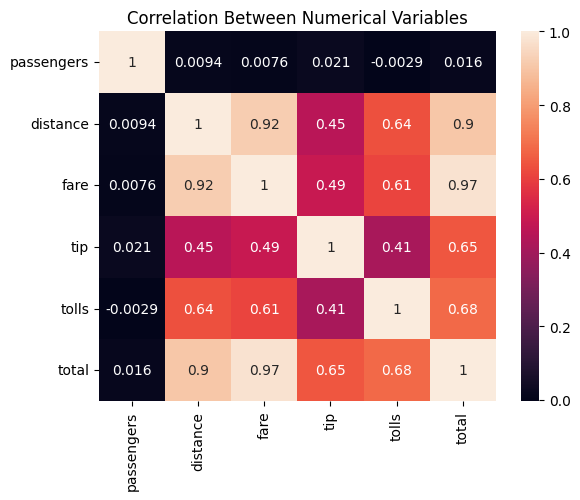

In [80]:
# Check the correlation between numerical columns
df.corr(numeric_only = True)

# Visualize via Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Between Numerical Variables")
plt.show()

### Longer taxi trips generally have a higher fare and total cost.

In [81]:
# Payment method and average total
# Visualize it 
print(df.groupby("payment")["total"].mean())

payment
cash           14.676849
credit card    20.071248
Name: total, dtype: float64


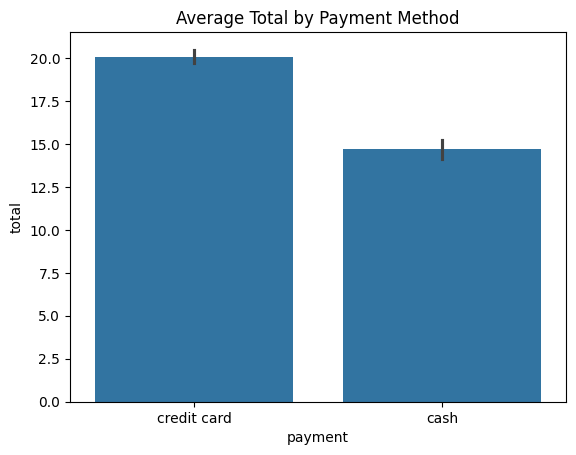

In [82]:
sns.barplot(x="payment", y="total", data=df)
plt.title("Average Total by Payment Method")
plt.show()

### The average taxi fare differs depending on the payment method. Credit-card and cash passengers do not have exactly the same average total.

In [83]:
# Pickup borough and average total
print(df.groupby("pickup_borough")["total"].mean())

pickup_borough
Bronx        22.765253
Brooklyn     19.236240
Manhattan    16.670507
Queens       31.660107
Name: total, dtype: float64


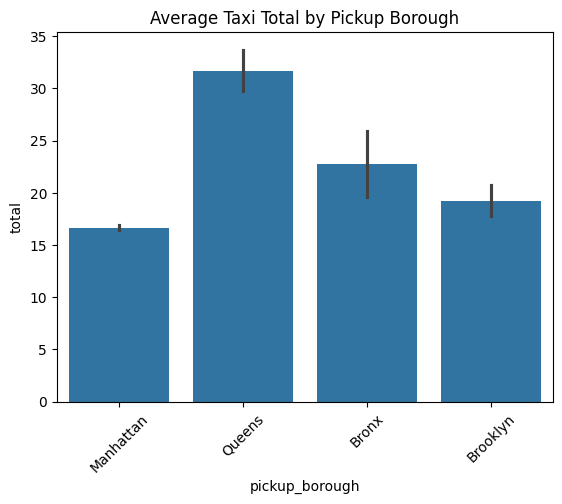

In [84]:
# Visualize it
sns.barplot(x="pickup_borough", y="total", data=df)
plt.title("Average Taxi Total by Pickup Borough")
plt.xticks(rotation=45)
plt.show()

### Some boroughs have higher average trip totals than others.This could happen because trips starting in different areas have different typical distances

In [85]:
# Dropoff borough and average total
print(df.groupby("dropoff_borough")["total"].mean())

dropoff_borough
Bronx            25.065985
Brooklyn         23.247246
Manhattan        16.801579
Queens           26.012565
Staten Island    76.865000
Name: total, dtype: float64


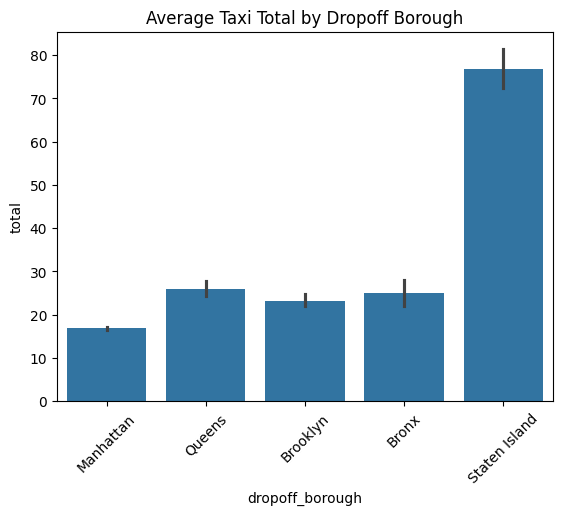

In [86]:
# Visualize it
sns.barplot(x="dropoff_borough", y="total", data=df)
plt.title("Average Taxi Total by Dropoff Borough")
plt.xticks(rotation=45)
plt.show()

### We can see that where the passenger is going also affects the average trip price.

In [87]:
# We can check whether weekday is more useful than the actual date.
# For that we need to convert the pickup time to datetime
df['pickup'] = pd.to_datetime(df['pickup'])

# THen we create a weekday column
df['weekday'] = df['pickup'].dt.day_name()

# Check the results
df[['pickup', 'weekday']].head()

,pickup,weekday
0,2019-03-23 20:21:09,Saturday
1,2019-03-04 16:11:55,Monday
2,2019-03-27 17:53:01,Wednesday
3,2019-03-10 01:23:59,Sunday
4,2019-03-30 13:27:42,Saturday


In [88]:
# Now we can find the average total for each weekday
print(df.groupby("weekday")["total"].mean())

weekday
Friday       18.658484
Monday       18.964223
Saturday     17.496912
Sunday       17.766313
Thursday     18.901735
Tuesday      18.888848
Wednesday    19.132288
Name: total, dtype: float64


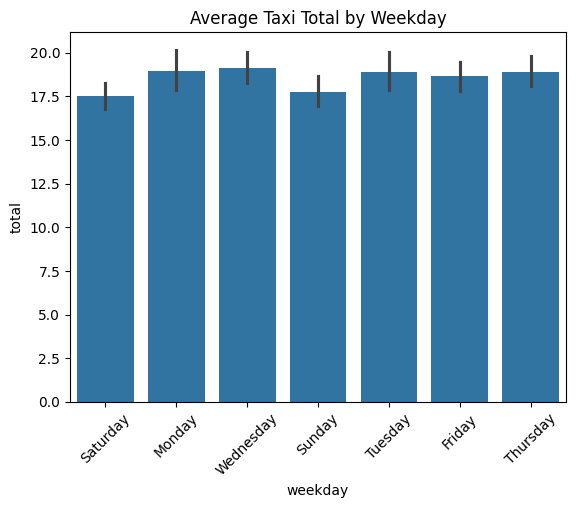

In [89]:
# Visualize it
sns.barplot(x="weekday", y="total", data=df)
plt.title("Average Taxi Total by Weekday")
plt.xticks(rotation=45)
plt.show()

### Looking at weekday is more useful than looking at individual dates and it helps us to understand general taxi usage patterns.

In [90]:
# Create a time_of_day column 
df['hour'] = df['pickup'].dt.hour

# Create a time categories as follows using a helper function
def get_time_of_day(hour):
    if hour < 6:
        return 'Night'
    elif hour < 12:
        return 'Morning'
    elif hour < 18:
        return 'Day'
    else:
        return 'Evening'

df['time_of_day'] = df['hour'].apply(get_time_of_day)
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_borough,dropoff_borough,weekday,hour,time_of_day
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Manhattan,Manhattan,Saturday,20,Evening
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Manhattan,Manhattan,Monday,16,Day
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Manhattan,Manhattan,Wednesday,17,Day
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Manhattan,Manhattan,Sunday,1,Night
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Manhattan,Manhattan,Saturday,13,Day


In [91]:
# Compare the time of day and visualize it
print(df.groupby("time_of_day")["total"].mean())

time_of_day
Day        19.196860
Evening    18.349149
Morning    17.652303
Night      19.128545
Name: total, dtype: float64


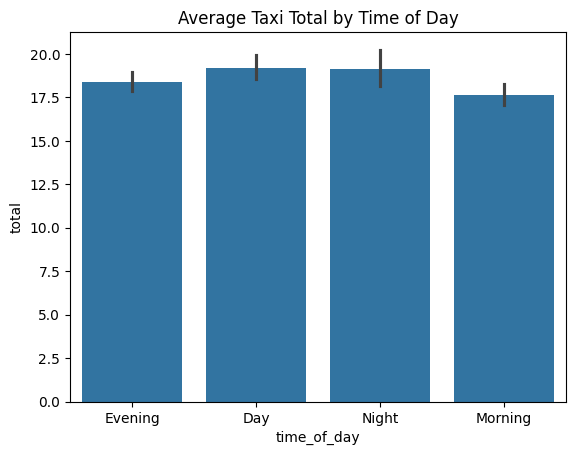

In [92]:
sns.barplot(x="time_of_day", y="total", data=df)
plt.title("Average Taxi Total by Time of Day")
plt.show()

### Dividing pickup time into morning, day, evening, and night can help identify when taxi trips tend to be more expensive or longer.

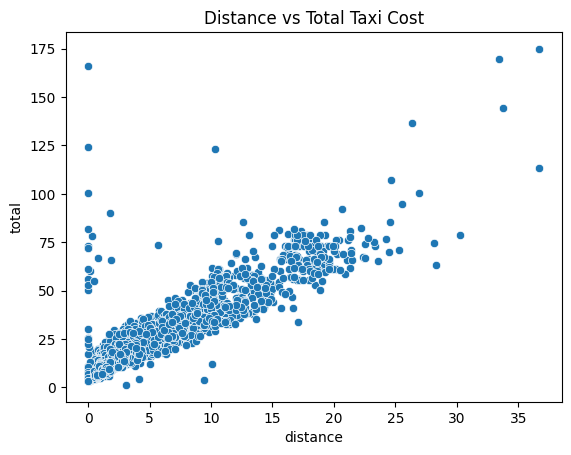

In [93]:
# Visualize the Distance vs Total
sns.scatterplot(x="distance", y="total", data=df)
plt.title("Distance vs Total Taxi Cost")
plt.show()

### As the distance increases, the total taxi cost generally increases.

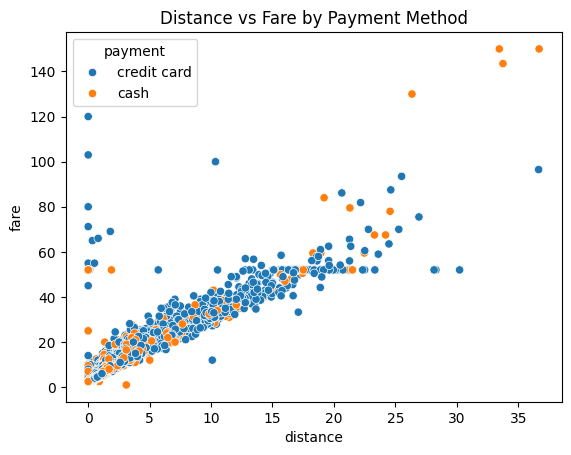

In [94]:
# Visualize Distance vs Fare
sns.scatterplot(x="distance", y="fare", hue="payment", data=df)
plt.title("Distance vs Fare by Payment Method")
plt.show()

### Longer trips generally have higher fares.